<font face="Arial" size="6"><b>P1: Neural Speaker Diarization with Lightweight Architectures</b></font><br />
<font face="Arial">COMP 6861 Winter 2026 Project</font><br />
<font face="Arial">Steven Markandu (#23740137)</font>



In this project, we (i.e. me, a team of one) implement and evaluate speaker diarization methods on the AMI Meeting Corpus using two approaches. The first is a traditional pipeline based on sliding-window segmentation, ECAPA-TDNN speaker embeddings, voice activity detection, and clustering-based speaker assignment.

The second is a neural diarization model that uses learned acoustic features to predict speaker activity more directly, allowing us to compare a modular
embedding-and-clustering pipeline against a more end-to-end learning-based approach.

We evaluate both models using Diarization Error Rate (DER) and analyze how design choices such as window size, VAD strategy, clustering parameters, and model training configuration affect performance.

## **Methodology**

For each model, the same experimental procedure is followed to ensure a fair comparison.

First, a hyperparameter search is performed on a development set of recordings. Multiple configurations are evaluated, and the best-performing parameters are selected based on Diarization Error Rate (DER).

Once the optimal configuration is chosen, the model is evaluated on a separate set of recordings. Each recording is processed independently, and performance metrics are computed per file.

A key constraint in diarization is that speaker identities differ across recordings. As a result, the advanced model remains unsupervised, avoiding fixed speaker classification approaches (e.g., predicting speaker IDs directly). Instead, it focuses on improving relative similarity between segments, which is sufficient for clustering-based diarization.


## **Limitations**

There are a few limitations in our system/project:

* **Use of Oracle Speech Activity**
  The baseline relies on ground-truth (oracle) speech segments, which removes errors from voice activity detection (VAD). While useful for isolating pipeline performance, this does not reflect real-world conditions, where VAD errors can significantly degrade performance.

* **Limited Dataset Size**
  Experiments are conducted on a small subset of AMI recordings due to computational constraints. This may limit the generalizability of results and increase sensitivity to recording-specific characteristics.

* **Simplified Clustering Approach**
  The baseline uses KMeans clustering, which assumes a fixed number of speakers and may struggle with overlapping speech or highly variable speaker characteristics.

* **No Explicit Overlap Handling**
  The pipeline does not explicitly model overlapping speech segments. As a result, segments with multiple active speakers are typically assigned to a single speaker, increasing diarization error.

* **Dependence on Pretrained Embeddings**
  Speaker representations are obtained from a pretrained ECAPA-TDNN model without task-specific fine-tuning. This may limit performance compared to fully trained or adapted diarization systems.

* **Hyperparameter Sensitivity**
  Performance depends on several hyperparameters (e.g., window size, smoothing), and the selected configuration may not generalize well to different datasets or recording conditions.


## **Evaluation**

Performance is measured using **Diarization Error Rate (DER)**, which quantifies the proportion of incorrectly labeled speech over time. DER is computed at the frame level and consists of three components [1]:

* **Missed Speech (Miss):**
  Speech present in the reference but not detected in the hypothesis (i.e., the system fails to identify speech segments).

* **False Alarm (FA):**
  Speech predicted by the system where no speech exists in the reference (i.e., non-speech is incorrectly labeled as speech).

* **Speaker Confusion (Conf):**
  Speech is detected, but assigned to the wrong speaker.

We calculate DER as such:


```text id="d3fws8"
DER = (Miss + False Alarm + Confusion) / Total Reference Speech
```

To ensure robust evaluation:

* A **collar tolerance** margin is applied around segment boundaries to reduce sensitivity to small timing misalignments. Any prediction errors within this margin are ignored during scoring.
* Predicted cluster labels are mapped to reference speaker identities prior to comparison

For each recording in the evaluation set:

1. Reference annotations and predicted segments are converted into frame-level speaker labels
2. Predicted cluster labels are mapped to ground-truth speakers
3. Frame-wise comparison is performed to compute:

   * Miss
   * False Alarm
   * Confusion
4. DER is computed for the recording

This produces a DER score and its components for each individual recording.

To summarize overall performance, results are aggregated across all evaluation recordings:

* **Mean DER:**
  The average DER across all recordings, representing overall system performance

* **Standard Deviation (Std):**
  Measures variability in performance across recordings, indicating consistency of the model

These statistics are computed as:

```text id="jg3i3y"
Mean DER = (1 / N) * Σ DER_i
```

```text id="2d0s0k"
Std DER = sqrt( (1 / N) * Σ (DER_i - Mean DER)^2 )
```

where ( DER_i ) is the DER for recording ( i ), and ( N ) is the number of evaluation recordings.


# Setup / Environment


## Install Source Code

In [1]:
%cd /content
!rm -r ./comp6861_project
!git clone https://github.com/smarkandu/comp6861_project.git

/content
rm: cannot remove './comp6861_project': No such file or directory
Cloning into 'comp6861_project'...
remote: Enumerating objects: 791, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 791 (delta 176), reused 159 (delta 79), pack-reused 529 (from 1)
Receiving objects: 100% (791/791), 165.46 KiB | 18.38 MiB/s, done.
Resolving deltas: 100% (452/452), done.


In [2]:
%env PROJECT_DIR=comp6861_project
%cd /content/comp6861_project

#Set seed (also done in code)
import sys
sys.path.append('/content/comp6861_project/src')
from utils.debug import set_seed
set_seed()

env: PROJECT_DIR=comp6861_project
/content/comp6861_project


## Download Data

Obtained via https://groups.inf.ed.ac.uk/ami/download/

## **Dataset**

The experiments are conducted using the **AMI Meeting Corpus**, a widely used benchmark for speaker diarization. The dataset consists of multi-speaker meeting recordings in which several participants engage in natural conversational speech. These recordings capture realistic conditions such as speaker overlap, short conversational turns, background noise, and varying speaking styles.

### **Audio Data**

In this work, we use the **single-channel Mix-Headset recordings** provided by the AMI corpus. Each meeting recording is stored as a `.wav` file (e.g., `ES2002a.Mix-Headset.wav`) and contains the mixed audio from all participants. These recordings are resampled (if necessary) and processed as continuous audio signals.

### **Annotations**

Ground-truth speaker annotations are obtained from the **AMI manual annotation set** (`ami_public_manual_1.6.2`). The annotations are provided in XML format and contain time-stamped segments indicating when each speaker is active.

Each annotation entry specifies:

* **Start time and end time** of a speech segment
* **Speaker identity** (e.g., A, B, C, D)
* Potentially overlapping segments when multiple speakers are active

These annotations are parsed and converted into a structured format of speaker events:

```text
(start_time, end_time, speaker_id)
```

or, in cases of overlap:

```text
(start_time, end_time, [speaker_ids])
```

### **Usage in the Pipeline**

The dataset is used in several ways within the diarization pipeline:

* **Speech Region Definition (Baseline):**
  Ground-truth annotations are used to define oracle speech regions, ensuring that only speech segments are processed and eliminating errors from speech activity detection.

* **Evaluation Ground Truth:**
  The annotations serve as the reference for computing Diarization Error Rate (DER). Both reference annotations and predicted segments are converted to frame-level representations for comparison.

* **Window Labeling (Optional / Advanced):**
  For certain analyses or extensions, annotation overlap with time windows can be used to assign speaker labels to individual segments.

### **Data Splitting**

Recordings are processed independently. The dataset is divided into:

* A **development set** used for hyperparameter tuning
* A **held-out evaluation set** used for final performance reporting

This separation ensures that evaluation results reflect generalization to unseen recordings.

In [3]:
%cd /content/comp6861_project/data/
!. ./wget2.sh
%cd /content/comp6861_project/

Streaming output truncated to the last 5000 lines.
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2012c.A.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/IS1005b.C.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/TS3004b.A.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2007d.A.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2009c.C.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/IS1006c.B.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2003b.D.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/IS1005a.A.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2016d.D.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/IS1006a.B.argumentstructs.xml  
  inflating: ami_public_manual_1.6.2/argumentation/ae/ES2008b.A.argumentstructs.xml  
  i

## Install Packages

In [4]:
%cd /content/comp6861_project
!pip install -r requirements2.txt

/content/comp6861_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 62.8 MB/s eta 0:00:00


# **Baseline Speaker Diarization System**

## Methodology

The baseline model is inspired by standard speaker diarization pipelines described in [1].

Our baseline model performs speaker diarization using a fully unsupervised pipeline:

```text
Speech Regions → Windows → Embeddings → Clustering → Post-processing → Segments → Evaluation (DER)
```

### <u>Speech Regions (Oracle)</u>

Ground-truth speech regions are used to define where speech occurs.
This avoids errors from voice activity detection and allows the system to focus purely on speaker discrimination.

### <u>Feature Extraction (Windows & Embeddings)</u>

Speech is divided into overlapping windows, and each window is converted into a fixed-dimensional representation using a pretrained speaker embedding model.

No model training is performed; embeddings are used directly.

 We use the ECAPA-TDNN model from SpeechBrain [6] in order to generate our embeddings for each sound file.

ECAPA_TDNN has the following [3]:
- An enhanced TDNN for speaker verification/diarization, built on the x-vector framework.
- Squeeze-and-Excitation blocks model channel interdependencies using global context for more expressive embeddings.
- 1D hierarchical skip connections enable richer, multi-scale frame-level feature extraction.
- Pools outputs across all SE-Res2Blocks rather than just the final layer, capturing both shallow and deep features.
- Channel- and context-dependent temporal attention allows the network to focus on different frames per channel.
- Achieves state-of-the-art results on VoxCeleb and AMI Meeting Corpus for both speaker verification and diarization tasks.

### <u>Clustering</u>

The embeddings are grouped using an **unsupervised clustering algorithm**, assigning a speaker label to each window.
Clustering is performed independently for each recording.


### <u>Post-processing</u>

The raw cluster labels are refined by:

* Smoothing label sequences
* Merging consecutive segments with the same label
* Removing very short segments

## Hyperparameter Tuning (Baseline)

A grid search is performed to optimize the baseline diarization pipeline using oracle speech activity. This removes VAD-related errors and allows tuning to focus on segmentation, clustering, and post-processing. Each configuration is evaluated using Diarization Error Rate (DER), and results are aggregated across recordings using mean and standard deviation.


### <u>Tuned Parameters</u>

* **Window Length (`window_sec`)**
  Controls segment duration for embedding extraction.
  Smaller → better temporal resolution, noisier embeddings.
  Larger → more stable embeddings, may miss short turns.

* **Hop Length (`hop_sec`)**
  Step size between windows.
  Smaller → more overlap, smoother predictions.
  Larger → less computation, but may miss transitions.

* **Clustering (`kmeans`)**
  Groups embeddings into speakers by minimizing intra-cluster variance.
  Directly affects speaker separation quality.

* **Smoothing (`smoothing`)**
  Reduces rapid label changes across time.
  Higher → more stable segments, but may remove short turns.

* **Merge Gap (`merge_gap`)**
  Merges same-speaker segments separated by small gaps.
  Helps reduce fragmentation.

* **Minimum Segment Duration (`min_seg_dur`)**
  Removes very short segments caused by noise or errors.

In [5]:
%cd /content/comp6861_project/
!python ./src/tune.py --config ./configs/tune_baseline.yml

/content/comp6861_project

=== Tuning Setup ===
config_stem:     tune_baseline
recordings:      ['ES2002a', 'ES2003a', 'ES2004a']
device:          cuda:0
num_configs:     32
ignore_overlap:  True
collar:          0.25
out_csv:         /content/comp6861_project/outputs/baseline_tuning_results.csv
summary_csv:     /content/comp6861_project/outputs/baseline_tuning_summary.csv

=== Config 1/32 ===
{'model_type': 'ecapa', 'speech_source': 'oracle', 'vad_threshold': 8e-05, 'min_speech_overlap': 0.5, 'window_sec': 2.0, 'hop_sec': 1.0, 'smoothing_kernel': 1, 'clustering_method': 'kmeans', 'n_neighbors': 10, 'merge_gap': 0.25, 'min_seg_dur': 0.5, 'use_cache': False, 'config_stem': 'tune_baseline'}
[Model] Using ECAPA-TDNN embeddings.
hyperparams.yaml: 1.92kB [00:00, 7.24MB/s]
embedding_model.ckpt: 100% 83.3M/83.3M [00:01<00:00, 58.4MB/s]
mean_var_norm_emb.ckpt: 100% 1.92k/1.92k [00:00<00:00, 13.0MB/s]
classifier.ckpt: 100% 5.53M/5.53M [00:00<00:00, 13.5MB/s]
label_encoder.txt: 129kB [00:00, 77.

## Evaluation (Baseline)

### DER (Baseline)

From a previous hyperparameter run, we obtained the following results:

```
=== Best Validation Config ===
config_id: 17
model_type: ecapa
speech_source: oracle
vad_threshold: 0.0001
min_speech_overlap: 0.5000
window_sec: 3.0000
hop_sec: 1.0000
smoothing_kernel: 1
clustering_method: kmeans
n_neighbors: 10
merge_gap: 0.2500
min_seg_dur: 0.5000
use_cache: False
mean_DER: 0.2072
std_DER: 0.0690
num_successful_recordings: 3
```



Therefore we'll use these to set our hyperparameters for evaluation (config file already set with these parameter values)

In [6]:
%cd /content/comp6861_project/
!python ./src/main.py --config ./configs/main_baseline_config.yml

/content/comp6861_project

=== Run Configuration ===
config stem:        main_baseline_config
audio_dir:        data/amicorpus
annotation_dir:   data/ami_public_manual_1.6.2
recording_ids:     ['ES2002b', 'ES2002c', 'ES2002d', 'ES2003b', 'ES2004b', 'ES2005a', 'ES2005b']
debug:            True
use_cache:        False

--- Model ---
model_type:       ecapa
window_sec:       3.0
hop_sec:          1
smoothing:        1

--- Clustering ---
method:           kmeans
n_neighbors:      10
merge_gap:        0.25
min_seg_dur:      0.5

--- Speech ---
speech_source:    oracle
min_overlap:      0.5
vad_threshold:    0.0001
=== Starting Diarization Pipeline ===

[1/7] Loading dataset...
[2/7] Selecting recordings...
recording ids:  ['ES2002b', 'ES2002c', 'ES2002d', 'ES2003b', 'ES2004b', 'ES2005a', 'ES2005b']
[3/7] Initializing model on cuda:0...
[Model] Using ECAPA-TDNN embeddings.
[4/7] Running diarization and evaluation...

=== Processing ES2002b ===
Recording ID: ES2002b
Audio duration: 2279.75s


### RTTM (Baseline)

We're able to compare the reference and predicted RTTMs as such:

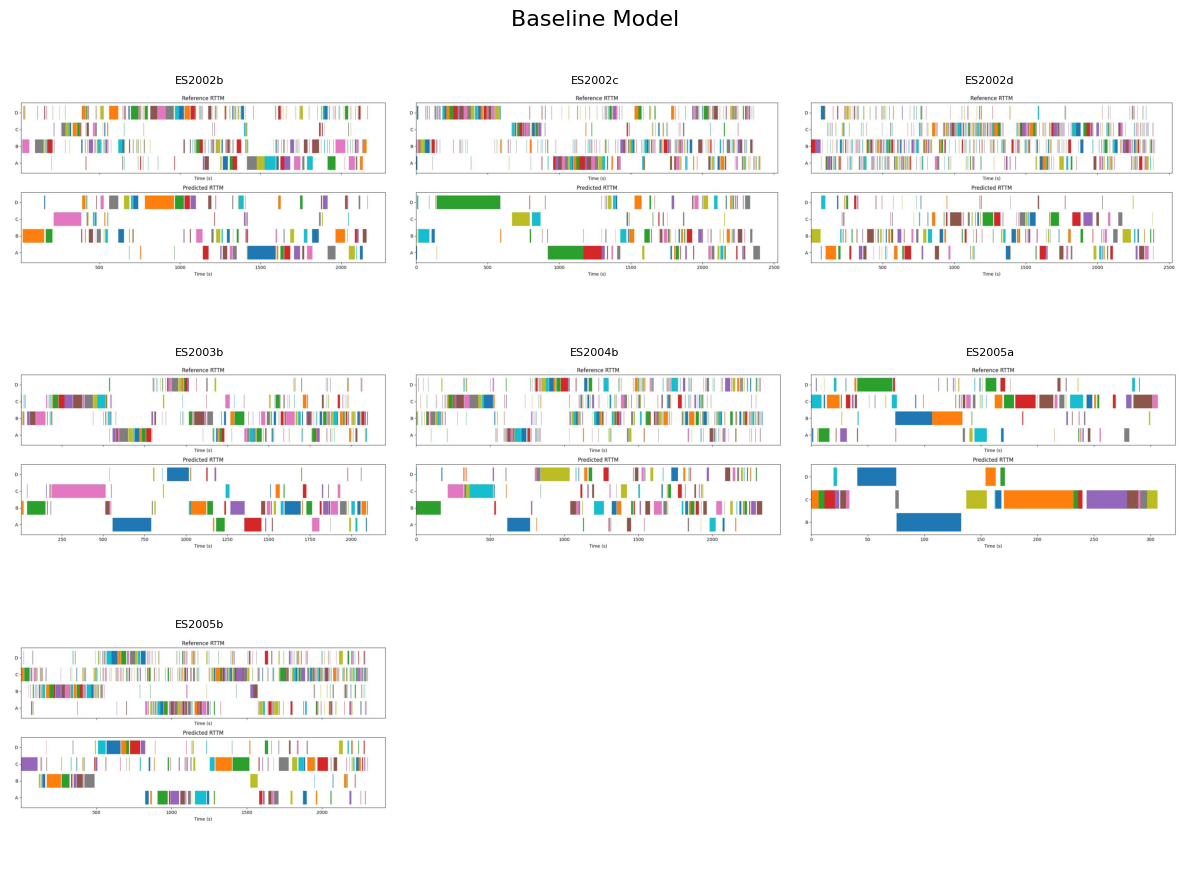

In [7]:
from pathlib import Path
from utils.rttm_utils import show_jpg_grid

ref_path = Path("/content/comp6861_project/outputs/rttm/main_baseline_config")
show_jpg_grid(ref_path, cols=3, title="Baseline Model")

# **Advanced Speaker Diarization System**

## **Motivation**

While the baseline system provides a simple and effective unsupervised pipeline, it relies on relatively basic clustering and embedding representations. The advanced model aims to improve performance by enhancing both the quality of speaker representations and the robustness of clustering, while still avoiding assumptions about fixed speaker identities across recordings.



### **Key Differences from Baseline**

The advanced system introduces the following improvements:

* **Stronger Embeddings:**
  The baseline uses ECAPA-TDNN embeddings, while the advanced model explores WavLM-based embeddings, which are pretrained on large-scale speech data and capture richer contextual and speaker information.

* **Improved Clustering:**
  Instead of relying solely on basic clustering, the advanced model uses **spectral clustering**, which better captures the structure of the embedding space and is more robust to non-linear separations between speakers.[4]

* **Automatic Speaker Estimation:**
  The number of speakers is estimated directly from the data using techniques such as eigengap analysis [4], removing the need for oracle speaker counts and making the system more realistic.

* **Refinement via Second Pass:**
  A second-pass clustering stage is applied on longer, more stable segments, allowing the system to refine speaker assignments and reduce noise from short or ambiguous regions.

* **Enhanced Post-processing:**
  Additional tuning of smoothing, segment merging, and duration thresholds improves temporal consistency and reduces fragmentation.

## **Methodology**

The overall pipeline remains similar in structure to the baseline:

```text
Speech Regions → Windows → Embeddings → Clustering → Post-processing → Segments
```

However, each stage is improved:

* **Embeddings:** WavLM replaces or complements ECAPA to provide richer representations.  WaveLM features the following [4]:
  * Pretrained speech representation model using self-supervised learning on large-scale unlabeled audio
  * Learns contextualized embeddings directly from raw waveform
Based on a Transformer architecture for modeling long-range dependencies
  * Trained with masked prediction and denoising objectives
  * Captures both speaker characteristics and speech content
Produces robust embeddings under noise, overlap, and varying conditions
  * Used in the Embeddings stage of the diarization pipeline
Improves clustering quality by providing more discriminative speaker features

* **Clustering:** Spectral clustering is used instead of K-Means
* **Speaker Count:** Estimated automatically rather than provided
* **Refinement:** A second-pass clustering step improves segment consistency


##**HyperParameter Tuning (Advanced)**

Again, we evaluate multiple configurations across the pipeline to identify those that minimize Diarization Error Rate (DER). This allows us to better balance segmentation quality, clustering accuracy, and temporal consistency.

### **Speech Regions (VAD-based)**

Speech regions are obtained using a SpeechBrain VAD model instead of oracle annotations.  Using a SpeechBrain VAD model instead of oracle annotations makes the system fully automatic and more realistic, enabling end-to-end diarization that generalizes to real-world data without requiring ground-truth speech labels.

The following parameters are tuned:

* **VAD Threshold (`vad_threshold_values`)**
  Controls how easily a frame is classified as speech.
  Lower values include more speech (but risk false alarms), while higher values are more conservative.

* **Minimum Speech Overlap (`min_speech_overlap_values`)**
  Specifies the minimum fraction of a window that must contain speech to be retained.
  Higher values enforce stricter filtering of partially speech segments.


### **Segmentation (Windowing)**

Detected speech regions are divided into overlapping windows for embedding extraction.

The following parameters are tuned:

* **Window Size (`window_values`)**
  Length of each audio segment (in seconds).
  Larger windows improve embedding stability, while smaller windows improve temporal resolution.

* **Hop Size (`hop_values`)**
  Step size between consecutive windows.
  Smaller hops increase overlap and smoothness but increase computational cost.


### **Feature Extraction**

Each window is converted into a fixed-dimensional speaker representation using a **pretrained ECAPA-TDNN model**.

* **Model Type (`model_types`)**
  Specifies the embedding model used.
  In this setup, ECAPA-TDNN is used for all configurations.

No additional training or fine-tuning is performed; embeddings are used directly.


### **Clustering**

Embeddings are grouped into speaker clusters using **spectral clustering**.

The following parameters are tuned:

* **Clustering Method (`clustering_values`)**
  Defines the clustering algorithm used (spectral clustering in this case).

* **Number of Neighbors (`n_neighbors_values`)**
  Controls the connectivity of the affinity graph.
  Lower values emphasize local structure, while higher values produce smoother, more global clustering.

Clustering is performed independently for each recording.


### **Post-processing**

Predicted speaker labels are refined to improve temporal consistency and reduce noise.

The following parameters are tuned:

* **Smoothing Kernel (`smoothing_values`)**
  Applies temporal smoothing to reduce rapid speaker label fluctuations.

* **Merge Gap (`merge_gap_values`)**
  Maximum allowable gap between adjacent segments of the same speaker for merging.
  Larger values reduce fragmentation.

* **Minimum Segment Duration (`min_seg_dur_values`)**
  Enforces a minimum length for speaker segments, removing very short segments that are likely errors.

### **Evaluation**

Each configuration is evaluated using **Diarization Error Rate (DER)**, computed per recording and aggregated across all recordings.

* **Collar (`collar`)**
  A tolerance window (0.25 seconds) around segment boundaries where errors are ignored.

* **Ignore Overlap (`ignore_overlap`)**
  Overlapping speech regions are excluded from evaluation.

Final results are reported as the **mean and standard deviation of DER** across all evaluated recordings.


In [8]:
%cd /content/comp6861_project/
!python ./src/tune.py --config ./configs/tune_advanced_light.yml

/content/comp6861_project

=== Tuning Setup ===
config_stem:     tune_advanced_light
recordings:      ['ES2002a', 'ES2003a', 'ES2004a']
device:          cuda:0
num_configs:     24
ignore_overlap:  True
collar:          0.25
out_csv:         /content/comp6861_project/outputs/tuning_results.csv
summary_csv:     /content/comp6861_project/outputs/tuning_summary.csv

=== Config 1/24 ===
{'model_type': 'wavlm', 'speech_source': 'speechbrain_vad', 'vad_threshold': 8e-05, 'min_speech_overlap': 0.5, 'window_sec': 2.0, 'hop_sec': 1.0, 'smoothing_kernel': 1, 'clustering_method': 'spectral', 'n_neighbors': 10, 'merge_gap': 0.25, 'min_seg_dur': 0.5, 'use_cache': False, 'config_stem': 'tune_advanced_light'}
[Model] Using WavLM embeddings.
preprocessor_config.json: 100% 215/215 [00:00<00:00, 802kB/s]
config.json: 58.6kB [00:00, 83.8MB/s]
model.safetensors: 100% 404M/404M [00:03<00:00, 134MB/s]
Loading weights: 100% 266/266 [00:00<00:00, 1081.21it/s, Materializing param=wavlm.masked_spec_embed]
model.

## Evaluation (Advanced - SpeechBrainVAD)


### DER (Advanced)

From a previous hyperparameter run, we obtained the following results:

```
=== Best Validation Config ===
config_id: 21
model_type: wavlm
speech_source: speechbrain_vad
vad_threshold: 0.0001
min_speech_overlap: 0.7000
window_sec: 3.0000
hop_sec: 1.0000
smoothing_kernel: 1
clustering_method: spectral
n_neighbors: 10
merge_gap: 0.2500
min_seg_dur: 0.5000
use_cache: False
mean_DER: 0.4066
std_DER: 0.0597
num_successful_recordings: 3
```



Therefore use this to set our hyperparameters for evaluation (config file set with these parameter values)

In [9]:
%cd /content/comp6861_project/
!python ./src/main.py --config ./configs/main_advanced_config.yml

/content/comp6861_project

=== Run Configuration ===
config stem:        main_advanced_config
audio_dir:        data/amicorpus
annotation_dir:   data/ami_public_manual_1.6.2
recording_ids:     ['ES2002b', 'ES2002c', 'ES2002d', 'ES2003b', 'ES2004b', 'ES2005a', 'ES2005b']
debug:            True
use_cache:        False

--- Model ---
model_type:       wavlm
window_sec:       3.0
hop_sec:          1.0
smoothing:        1

--- Clustering ---
method:           spectral
n_neighbors:      10
merge_gap:        0.25
min_seg_dur:      0.5

--- Speech ---
speech_source:    speechbrain_vad
min_overlap:      0.7
vad_threshold:    0.0001
=== Starting Diarization Pipeline ===

[1/7] Loading dataset...
[2/7] Selecting recordings...
recording ids:  ['ES2002b', 'ES2002c', 'ES2002d', 'ES2003b', 'ES2004b', 'ES2005a', 'ES2005b']
[3/7] Initializing model on cuda:0...
[Model] Using WavLM embeddings.
Loading weights: 100% 266/266 [00:00<00:00, 882.92it/s, Materializing param=wavlm.masked_spec_embed] 
[4/7] Run

### RTTM (Advanced)

And we're able to compare the refence and predicted RTTM files down below for each soundfile tested.  As you can see, they're more or less the same, in terms of structure.  

Note that we merge segments in the predictions if its the same speaker, so it will look less fragmented than the reference RTTM.

Also if you see one solid time interval with one colour in the prediction graph, but see mutiple (tight) segments with different colours in the reference graph, it's because of this.  We only consider one speaker if the speech is overlapped for an interval.

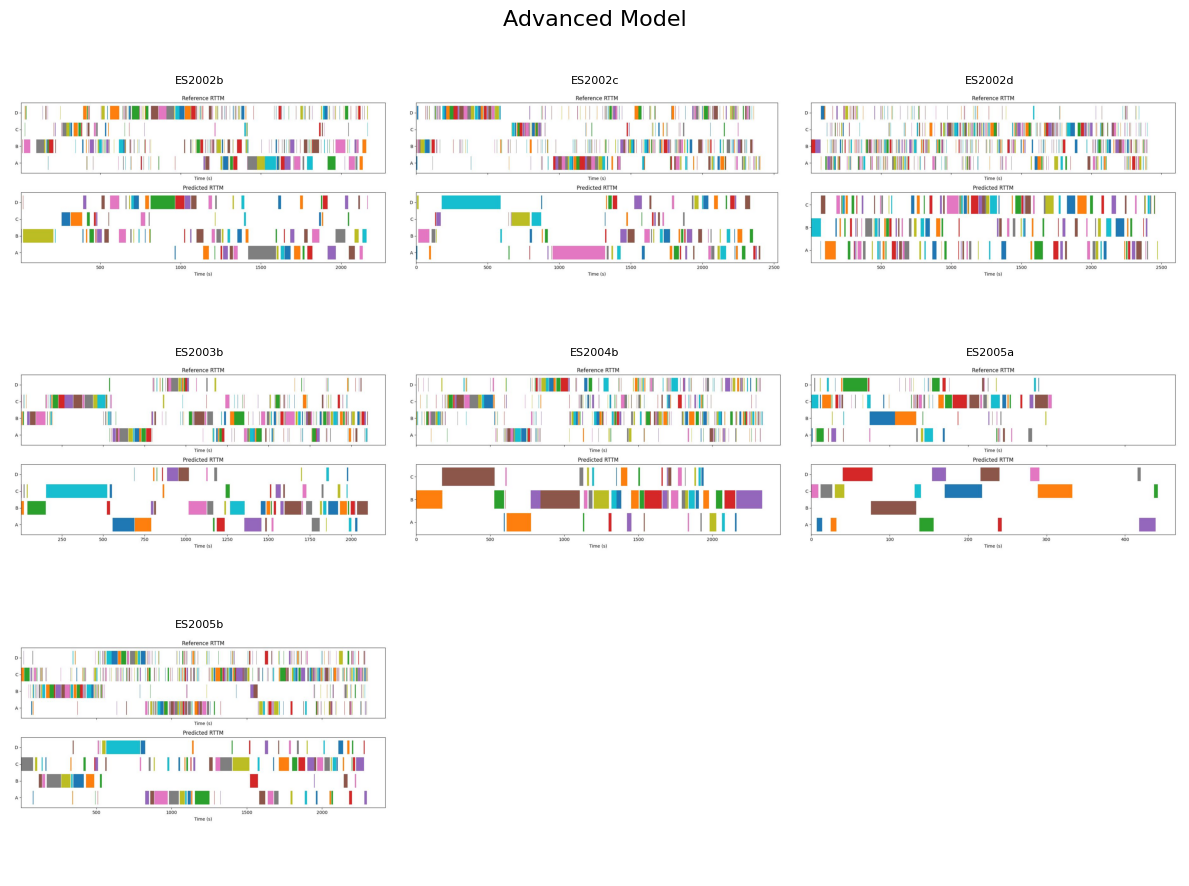

In [10]:
from pathlib import Path
from utils.rttm_utils import show_jpg_grid

ref_path = Path("/content/comp6861_project/outputs/rttm/main_advanced_config")
show_jpg_grid(ref_path, 3, "Advanced Model")

# Overall Analysis

## DER

To summarize our results:


| Model                         | Mean DER ↓ | Std DER |
|------------------------------|-----------:|--------:|
| Baseline (ECAPA + KMeans + Oracle)    |     0.1256     |   0.0528     |
| Advanced (WavLM + Spectral + SpeechBrainVAD)|     0.2488      |   0.1664     |

We observe the following:

* Key difference:
  * Baseline uses oracle (ground-truth) speech segments
  * Advanced model must estimate speech regions using VAD
  * This makes the advanced task significantly harder and affects comparison

Baseline model (ECAPA + KMeans + Oracle)
* Mean DER: 0.1256, Std: 0.0528
* Strong accuracy and stability
* Operates under ideal conditions (perfect speech segmentation)
* Only solves speaker discrimination and clustering
* Avoids errors from:
  * Missed speech
  * False alarms at segmentation stage


Advanced model (WavLM + Spectral + SpeechBrain VAD)
* Mean DER: 0.2488, Std: 0.1664
* Must first predict speech regions using VAD
* Introduces additional error sources:
  * Missed speech (speech not detected)
  * False alarms (non-speech detected as speech)
  * Poor segment boundaries
* These errors propagate and increase overall DER

Interpretation
* Higher DER is expected due to increased task complexity
* Advanced model solves a more realistic end-to-end diarization problem
* Performance gap reflects:
  * Added difficulty of speech segmentation
  * Not just differences in embeddings or clustering

Overall
* Oracle vs VAD systems are not directly equivalent comparisons
* VAD-based system operates under more realistic and harder conditions
* Advanced model remains competitive without ground-truth segmentation
* Improving VAD or jointly optimizing segmentation and clustering could reduce the gap


## RTTM

We observe the following in regards to the RTTM diagrams:

* RTTM plots compare reference (top) vs predicted (bottom) speaker segments across AMI recordings
* Structure is consistent across recordings and models, enabling direct comparison

Baseline model

* More fragmented predictions with many short segments, gaps, and rapid switches
* Poorer temporal alignment with reference
* Struggles with stable speaker boundaries (e.g., ES2002c, ES2004b)
* Indicates sensitivity to window-level variation and weaker clustering consistency
* Leads to higher confusion and false alarms

Advanced model

* Longer, more continuous segments
* Better alignment with reference speech regions
* More stable speaker assignments (e.g., ES2002d, ES2003b)
* Fewer unnecessary speaker switches and clearer segment boundaries
* Better preservation of speaker identity over time

Common behavior across both models

* Predictions appear smoother than reference due to merging of consecutive same-speaker segments
* Assumes a single speaker per time interval (no overlap modeling)
* In overlap regions, reference shows multiple short segments while prediction shows one continuous segment
* This can cause missed speaker changes and increased confusion

Overall

* Advanced model produces less fragmented, more temporally consistent outputs
* Shows better alignment with ground truth and improved diarization quality, consistent with lower DER


# Conclusion

The results demonstrate that while the baseline system achieves lower DER and greater stability, this performance is obtained under ideal conditions using oracle speech segments. In contrast, the advanced system operates in a fully automatic setting, where speech regions must be estimated using VAD, introducing additional sources of error and increasing overall task complexity.

Despite this, the advanced model produces more structured and temporally consistent segmentations and achieves reasonable performance given the absence of ground-truth segmentation. These findings highlight that the performance gap is largely driven by the added difficulty of speech activity detection rather than limitations in embedding or clustering alone.

Overall, the advanced system provides a more realistic representation of end-to-end diarization, and future improvements in VAD accuracy or joint optimization of segmentation and clustering could further reduce the gap and improve overall performance.

# References

**[1]** X. Anguera Miró, S. Bozonnet, N. Evans, C. Fredouille, G. Friedland, and O. Vinyals, "Speaker diarization: A review of recent research," *IEEE Trans. Audio, Speech, Lang. Process.*, vol. 20, no. 2, pp. 356–370, Feb. 2012, doi: 10.1109/TASL.2011.2125954.
URL: https://dl.acm.org/doi/abs/10.1109/TASL.2011.2125954


**[2]** N. Dawalatabad, M. Ravanelli, F. Grondin, J. Thienpondt, B. Desplanques, and H. Na, "ECAPA-TDNN embeddings for speaker diarization," in *Proc. Interspeech 2021*, pp. 3560–3564, doi: 10.21437/Interspeech.2021-941.
URL: https://www.isca-archive.org/interspeech_2021/dawalatabad21_interspeech.html


**[3]** B. Desplanques, J. Thienpondt, and K. Demuynck, "ECAPA-TDNN: Emphasized channel attention, propagation and aggregation in TDNN based speaker verification," in *Proc. Interspeech 2020*, pp. 3830–3834, doi: 10.21437/Interspeech.2020-2650.
URL: https://www.isca-archive.org/interspeech_2020/desplanques20_interspeech.html

**[4]** S. Chen, C. Wang, Z. Chen, Y. Wu, S. Liu, J. Li, N. Raj, and F. Wei,
“WavLM: Large-Scale Self-Supervised Pre-Training for Full Stack Speech Processing,”
IEEE Journal of Selected Topics in Signal Processing, vol. 16, no. 6, pp. 1505–1518, 2022.
Available: https://arxiv.org/abs/2110.13900

**[5]** U. von Luxburg, "A tutorial on spectral clustering," *Stat. Comput.*, vol. 17, no. 4, pp. 395–416, Dec. 2007, doi: 10.1007/s11222-007-9033-z.
URL: https://link.springer.com/article/10.1007/s11222-007-9033-z

**[6]** SpeechBrain, "SpeechBrain: Conversational AI with SpeechBrain," [Online]. Available: https://speechbrain.github.io/. [Accessed: 26-Apr-2026].

